## Modelo de Red Neuronal para Potabilidad del Agua

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc, roc_curve, roc_auc_score
)


#### Carga de datos


In [11]:
data_raw = pd.read_csv('./Datos_Etapa-2.csv', sep=',', na_values=['?'], encoding='utf-8')
data_raw.head()


,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,NO
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,NO
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,NO
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,NO
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,NO


#### Exploración rápida


In [12]:
data_raw.describe()


,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000
mean,7.080804,196.369481,22014.092415,7.122241,333.775784,426.205171,14.284921,66.396281,3.966731
std,1.594369,32.879680,8768.570852,1.583143,41.416864,80.824123,3.308232,16.174983,0.780354
min,0.000000,47.430000,320.940000,0.350000,129.000000,181.480000,2.200000,0.740000,1.450000
25%,6.090000,176.847500,15666.687500,6.130000,307.695000,365.735000,12.070000,55.847500,3.440000
50%,7.040000,196.965000,20927.830000,7.130000,333.070000,421.885000,14.220000,66.620000,3.955000
75%,8.060000,216.670000,27332.760000,8.112500,359.950000,481.790000,16.560000,77.337500,4.500000
max,14.000000,323.120000,61227.200000,13.130000,481.030000,753.340000,28.300000,124.000000,6.740000


#### Preprocesamiento


In [13]:
data = data_raw.copy()

# Asegurar que la variable objetivo sea numérica (0/1)
if data['Potabilidad'].dtype == object:
    data['Potabilidad'] = data['Potabilidad'].str.strip().str.upper().map({'NO': 0, 'SI': 1})

# Respaldo por si ya viene numérica como texto
data['Potabilidad'] = pd.to_numeric(data['Potabilidad'], errors='coerce')

# Variables predictoras: todas las columnas excepto la variable objetivo
feature_cols = [c for c in data.columns if c != 'Potabilidad']

# Forzar columnas predictoras a numéricas e imputar faltantes
for col in feature_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

imputer = SimpleImputer(strategy='mean')
data[feature_cols] = imputer.fit_transform(data[feature_cols])

# Eliminar filas donde la etiqueta no pudo mapearse
data = data.dropna(subset=['Potabilidad']).copy()
data['Potabilidad'] = data['Potabilidad'].astype(int)

print("Variables usadas:", feature_cols)
print("Total variables predictoras:", len(feature_cols))
print("Distribución Potabilidad:")
print(data['Potabilidad'].value_counts(dropna=False))



Variables usadas: ['pH', 'Dureza', 'Sólidos', 'Cloraminas', 'Sulfatos', 'Conductividad', 'Carbono_orgánico', 'Trihalometanos', 'Turbidez']
Total variables predictoras: 9
Distribución Potabilidad:
Potabilidad
0    1998
1    1278
Name: count, dtype: int64


#### División de datos


In [14]:
train, test = train_test_split(data, test_size=0.2, random_state=9)

x_train = train.drop(['Potabilidad'], axis=1)
y_train = train['Potabilidad']
x_test = test.drop(['Potabilidad'], axis=1)
y_test = test['Potabilidad']

print("Train:", x_train.shape, "Test:", x_test.shape)


Train: (2620, 9) Test: (656, 9)


#### Escalado de variables


In [15]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



#### Modelo: Red Neuronal (MLP) y búsqueda de hiperparámetros


In [16]:
mlp = MLPClassifier(random_state=77, max_iter=700, early_stopping=True)

param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [32, 64]
}

kfold = KFold(n_splits=10, shuffle=True, random_state=77)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=kfold,
    n_jobs=-1,
    scoring='recall'
)



In [17]:
grid.fit(x_train_scaled, y_train)
best_model = grid.best_estimator_
print("Mejores hiperparámetros:", grid.best_params_)



Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.001, 'batch_size': 64, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}


#### Evaluación del modelo


In [18]:
y_pred = best_model.predict(x_test_scaled)
y_proba = best_model.predict_proba(x_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Accuracy:  0.6692
Precision: 0.7053
Recall:    0.2617
F1-score:  0.3818

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.71      0.26      0.38       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656



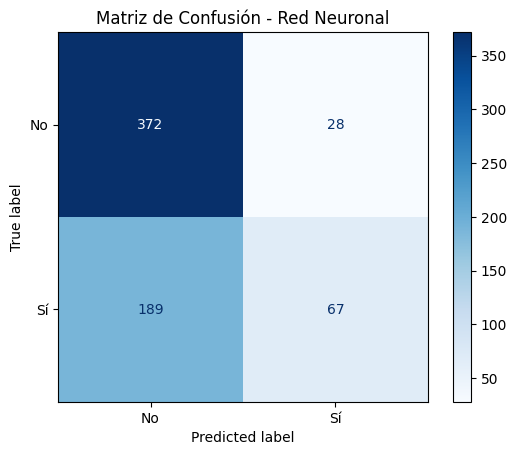

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Red Neuronal")
plt.show()


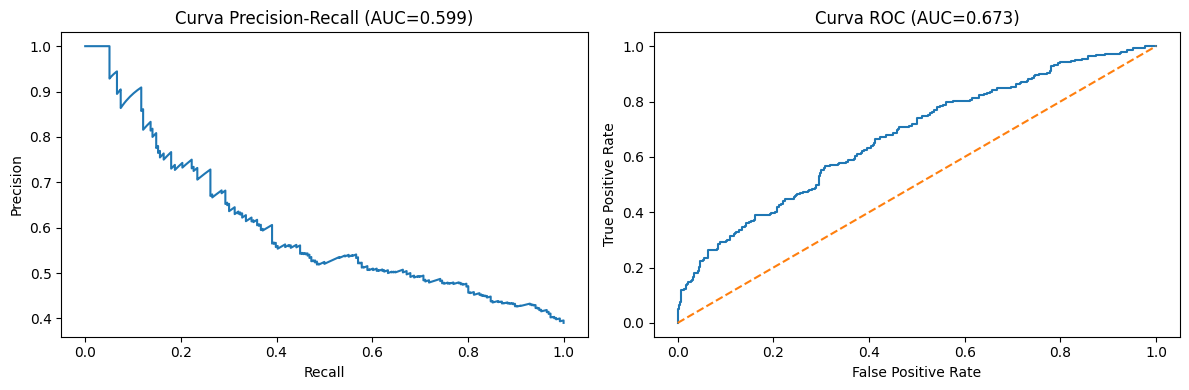

In [20]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Curva Precision-Recall (AUC={pr_auc:.3f})")

plt.subplot(1,2,2)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curva ROC (AUC={roc_auc:.3f})")

plt.tight_layout()
plt.show()


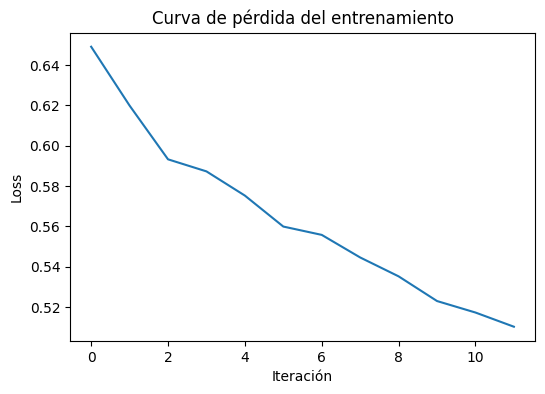

In [21]:
if hasattr(best_model, "loss_curve_"):
    plt.figure(figsize=(6,4))
    plt.plot(best_model.loss_curve_)
    plt.xlabel("Iteración")
    plt.ylabel("Loss")
    plt.title("Curva de pérdida del entrenamiento")
    plt.show()


In [23]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.4 MB/s eta 0:00:00


In [24]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import pandas as pd

# Opcional: forzar tracking local en carpeta mlruns del notebook
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Potabilidad_RedNeuronal_Experimento")

with mlflow.start_run(run_name="mlp_final_export"):
    # métricas/params (si ya las tienes, reutilízalas)
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)

    # firma del modelo
    input_example = pd.DataFrame(x_test.head(5), columns=x_test.columns)
    signature = infer_signature(x_test_scaled[:5], best_model.predict(x_test_scaled[:5]))

    # exporta en mlruns/.../models/m-xxxx/artifacts
    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="modelo_potabilidad_red_neuronal",
        registered_model_name="Modelo_Potabilidad_RedNeuronal",
        signature=signature,
        input_example=input_example
    )

    print("Run ID:", mlflow.active_run().info.run_id)


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/09 01:26:07 INFO mlflow.tracking.fluent: Experiment with name 'Potabilidad_RedNeuronal_Experimento' does not exist. Creating a new experiment.
2026/03/09 01:26:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 01:26:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternat

Run ID: f5ec0cda5c48461cb0ad09422843f1b0


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_model_registry/utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
Successfully registered model 'Modelo_Potabilidad_RedNeuronal'.
Created version '1' of model 'Modelo_Potabilidad_RedNeuronal'.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Resumen
- Estructura basada en `MachineLearning_YeissonGalindo.ipynb`.
- Se usan **todas** las variables predictoras (9):
  `pH`, `Dureza`, `Sólidos`, `Cloraminas`, `Sulfatos`, `Conductividad`, `Carbono_orgánico`, `Trihalometanos`, `Turbidez`.
